Testes de single qubit para estudo

Para classificar o seu dataset sintético (como o do círculo) usando o código do seu arquivo single_qubit.py, você precisará integrar as funções do circuito quântico com um otimizador clássico do scipy.optimize.

O fluxo consiste em inicializar os parâmetros quânticos, calcular os estados ideais de referência para cada classe, e minimizar a função de custo (single_cost_function) usando os seus dados de treino.

Entendendo os Componentes do seu Código:

representatives(n_classes, qubits_lab): Como o círculo possui duas classes (0 para fora e 1 para dentro), você usará n_classes=2 e qubits_lab=1.
Essa função vai gerar os estados ideais (alvos) na Esfera de Bloch: o vetor $[1, 0]^T$ ($|0\rangle$) para a classe 0 e $[0, 1]^T$ ($|1\rangle$) para a classe 1.

single_qubit_circuit: Repare que o seu circuito quântico realiza rotações baseadas em phi = theta[i] + w[i]*x. Como o seu dataset do círculo possui duas dimensões ($x \in \mathbb{R}^2$), o seu vetor de entrada x possui tamanho 2. Para que a multiplicação vetorial funcione corretamente no loop do seu código, os pesos $w[i]$ e parâmetros $\theta[i]$ precisam estar alinhados com a dimensionalidade dos dados de entrada.

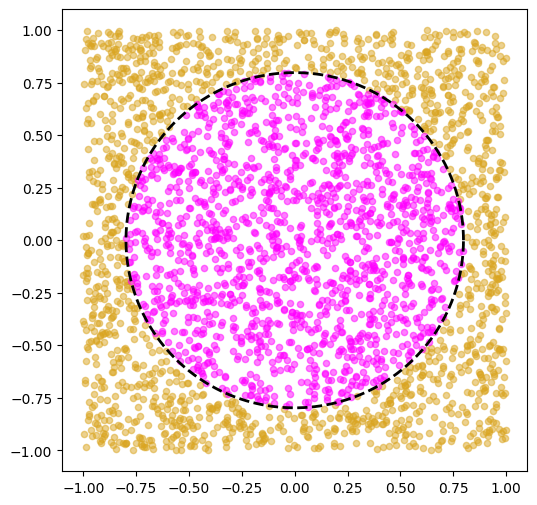

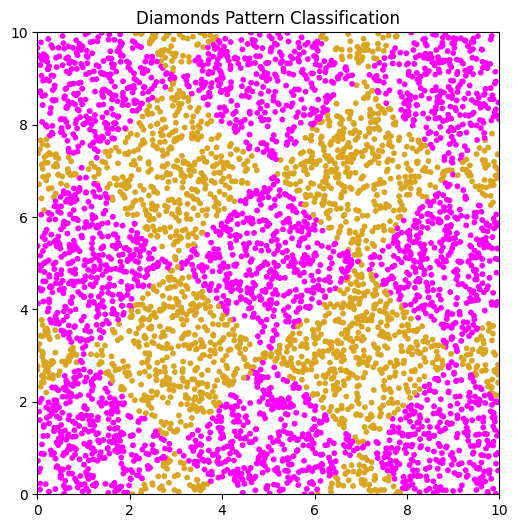

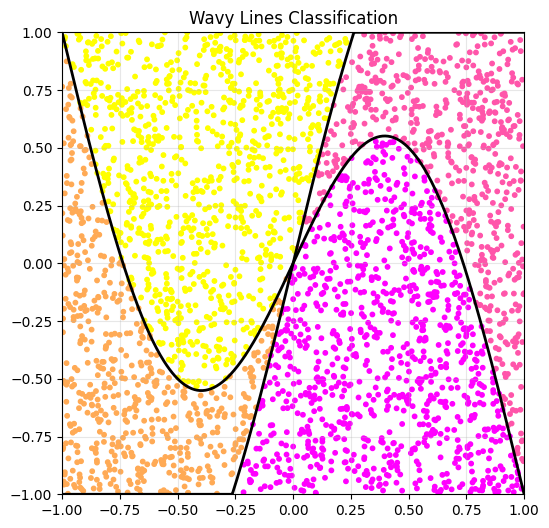

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from datasets import circle, plot_circle

In [2]:
data, (centers, radii) = circle(samples=3000, random_seed=42)

In [3]:
#Train/test split
data, (centers, radii) = circle(samples=3000, random_seed=42)
x = np.array([i[0] for i in data])
y = np.array([i[1] for i in data])

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y) #stratify allows to have a balance amount of labels in each split

Como a equação define um vetor de 3 dimensões $\vec{\phi}(\vec{x}) = (\phi_1(\vec{x}), \phi_2(\vec{x}), \phi_3(\vec{x}))$, isso significa que para cada camada do seu circuito, tanto os parâmetros bias $\vec{\theta}$ quanto os pesos $\vec{w}$ e os dados de entrada $\vec{x}$ precisam ter exatamente o mesmo tamanho: 3 dimensões.

Como o seu dataset do círculo (ou as componentes principais do Iris) possui apenas 2 dimensões ($x_0, x_1$), o broadcasting falha porque o vetor $\vec{x}$ original não tem a terceira componente para multiplicar com a terceira componente de $\vec{w}$.Para corrigir isso mantendo a lógica exata de produto Hadamard ($\vec{w} \circ \vec{x}$) sugerida pelo artigo, a estratégia ideal é realizar o Padding (preenchimento) dos seus dados clássicos antes de enviá-los ao otimizador, estendendo $\vec{x}$ para 3 dimensões de forma neutra.

In [14]:
# Aplica o Padding para adicionar uma 3ª dimensão preenchida com zeros
# (0, 0) significa não adicionar linhas no início/fim
# (0, 1) significa adicionar 1 coluna extra no final do array
X_train_padded = np.pad(x_train, ((0, 0), (0, 1)), mode='constant', constant_values=0)
X_test_padded = np.pad(x_test, ((0, 0), (0, 1)), mode='constant', constant_values=0)

# Agora os seus dados têm formato (N_amostras, 3), casando com w e theta!

In [17]:
np.shape(X_train_padded), np.shape(X_test_padded)

((2400, 3), (600, 3))

In [6]:
import numpy as np
from scipy.optimize import minimize
from sklearn.metrics import accuracy_score
from single_qubit import (single_qubit_params, pack_params, representatives,
                          single_cost_function, single_unpack_params, single_qubit_predict)

In [26]:
# 1. Configurações do Modelo Quântico
n_layers = 6      # Número de camadas do circuito quântico (ansatz)
n_classes = 2     # Classificação binária (dentro ou fora do círculo)
qubits_lab = 1    # Estamos usando um único qubit

In [27]:
# 2. Gerar os estados quânticos de referência (alvos para cada classe)
reprs = representatives(n_classes, qubits_lab)

In [28]:
# 3. Inicializar os parâmetros quânticos aleatoriamente (theta, w, alpha)
# O formato de theta e w gerado pela sua função lida nativamente com arrays n_layers x 3
theta_init, w_init, alpha_init = single_qubit_params(n_layers, n_classes)

In [29]:
# Empacotar os parâmetros em um único vetor unidimensional para o scipy.minimize
initial_params = pack_params(theta_init, w_init, alpha_init)

print("Iniciando o treinamento do Single Qubit Classifier...")

Iniciando o treinamento do Single Qubit Classifier...


In [30]:
# 4. Otimização Clássica (Treinamento)
# Passamos a função de custo, os parâmetros iniciais e os dados de treino como argumentos extras (args)
result = minimize(
    fun=single_cost_function,
    x0=initial_params,
    args=(X_train_padded, y_train, n_layers, n_classes, reprs),
    method='COBYLA',  # Método baseado em regiões de confiança, excelente para otimização sem derivadas (Gradient-Free)
    options={'maxiter': 200}  # Limite de iterações para testar o comportamento
)

In [31]:
# 5. Desempacotar os parâmetros ótimos encontrados pelo otimizador
optimal_params = result.x
theta_opt, w_opt, alpha_opt = single_unpack_params(optimal_params, n_layers, n_classes)

print("\nOtimização concluída!")
print(f"Sucesso: {result.success}")
print(f"Valor final da função de custo: {result.fun}")


Otimização concluída!
Sucesso: False
Valor final da função de custo: 609.527298573783


In [32]:
# 6. Avaliação do Modelo (Predição)
# Usando os parâmetros otimizados para prever as classes no conjunto de teste
y_pred_train = single_qubit_predict(X_train_padded, n_layers, n_classes, theta_opt, w_opt, reprs)
y_pred_test = single_qubit_predict(X_test_padded, n_layers, n_classes, theta_opt, w_opt, reprs)

# Calcular a acurácia
acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

print(f"\nAcurácia no Treino: {acc_train * 100:.2f}%")
print(f"Acurácia no Teste: {acc_test * 100:.2f}%")


Acurácia no Treino: 85.00%
Acurácia no Teste: 86.33%


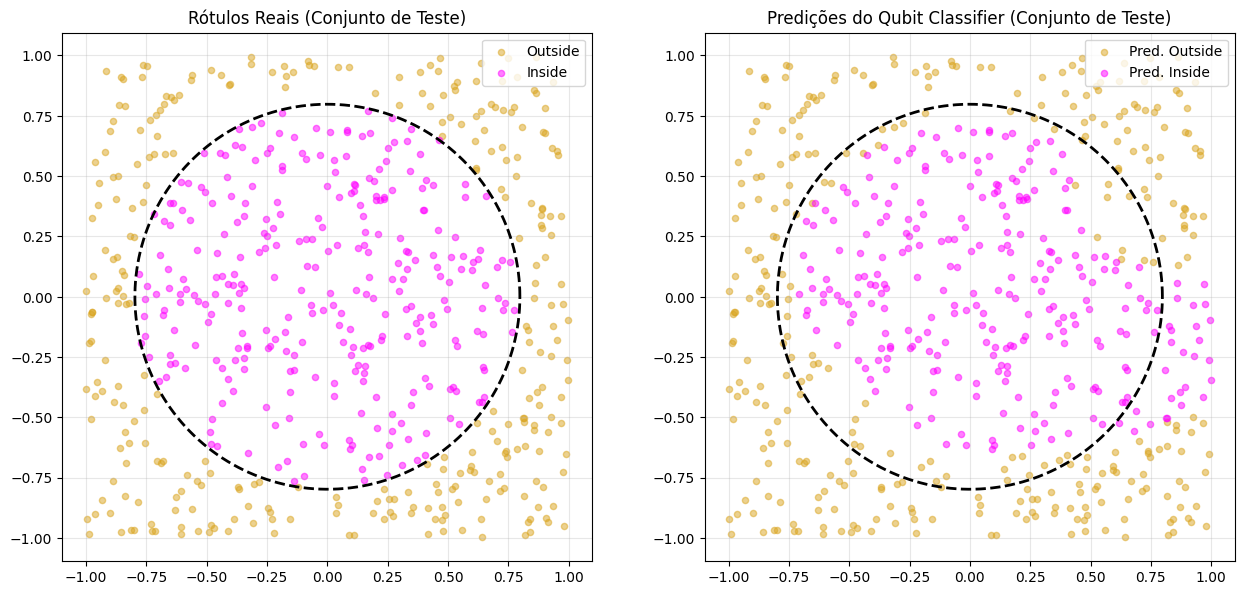

In [33]:
#Abordagem 1: Plotar Comparativo (Lado a Lado)
#eaproveitar quase toda a estrutura da sua função plot_circle. A principal diferença é que, em vez de passar as etiquetas reais (y), 
# você passará as predições geradas pela função single_qubit_predict do seu modelo.

def plot_quantum_predictions(X_data, y_real, y_pred, centers, radii, title_suffix=""):
    """
    X_data: Pode ser o X_test original (N, 2) ou o X_test_padded (N, 3).
            O scatter usará apenas as duas primeiras colunas clássicas.
    """
    center = centers[0]
    radius = radii[0]
    theta_vals = np.linspace(0, 2*np.pi, 200)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))
    
    # --- GRÁFICO 1: GABARITO REAL ---
    ax1.scatter(X_data[y_real == 0, 0], X_data[y_real == 0, 1], c='goldenrod', alpha=0.5, s=20, label='Outside')
    ax1.scatter(X_data[y_real == 1, 0], X_data[y_real == 1, 1], c='fuchsia', alpha=0.5, s=20, label='Inside')
    ax1.plot(center[0] + radius * np.cos(theta_vals), center[1] + radius * np.sin(theta_vals), 'k--', linewidth=2)
    ax1.set_title(f"Rótulos Reais {title_suffix}")
    ax1.set_aspect('equal')
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    # --- GRÁFICO 2: PREDIÇÃO DO QUBIT ---
    ax2.scatter(X_data[y_pred == 0, 0], X_data[y_pred == 0, 1], c='goldenrod', alpha=0.5, s=20, label='Pred. Outside')
    ax2.scatter(X_data[y_pred == 1, 0], X_data[y_pred == 1, 1], c='fuchsia', alpha=0.5, s=20, label='Pred. Inside')
    ax2.plot(center[0] + radius * np.cos(theta_vals), center[1] + radius * np.sin(theta_vals), 'k--', linewidth=2)
    ax2.set_title(f"Predições do Qubit Classifier {title_suffix}")
    ax2.set_aspect('equal')
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# --- COMO CHAMAR DEPOIS DO TREINAMENTO ---
# Gerando as predições com os parâmetros ótimos encontrados
y_pred_test = single_qubit_predict(X_test_padded, n_layers, n_classes, theta_opt, w_opt, reprs)

# Plotando o resultado para o conjunto de teste
plot_quantum_predictions(X_test_padded, y_test, y_pred_test, centers, radii, title_suffix="(Conjunto de Teste)")

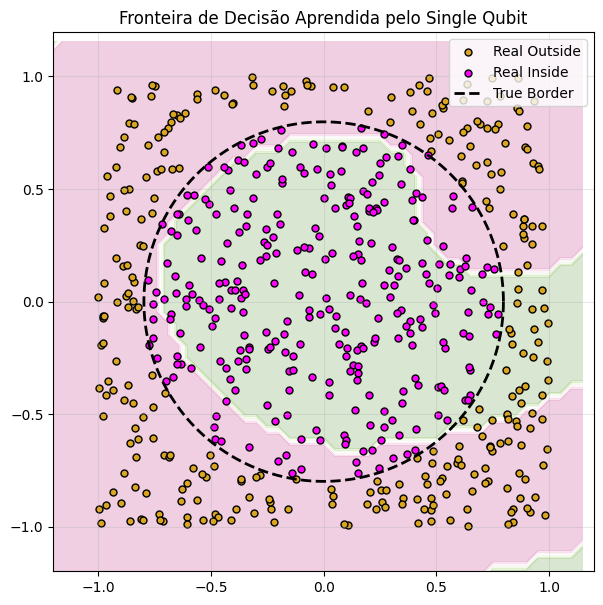

In [34]:
#Abordagem 2: Plotar a Fronteira de Decisão (Decision Boundary)
#Como o classificador quântico mapeia os dados clássicos para a Esfera de Bloch e tenta separá-los usando o equador, é fascinante ver como essa fronteira de decisão "quântica" se projeta de volta no plano bidimensional clássico.
#Para fazer isso, geramos uma grade densa de pontos (meshgrid) sobre o espaço do gráfico e pedimos para o qubit classificar cada ponto.

def plot_quantum_decision_boundary(X_data, y_real, n_layers, n_classes, theta_opt, w_opt, reprs, centers, radii):
    # 1. Definir os limites do gráfico com base nos seus dados
    x_min, x_max = X_data[:, 0].min() - 0.2, X_data[:, 0].max() + 0.2
    y_min, y_max = X_data[:, 1].min() - 0.2, X_data[:, 1].max() + 0.2
    
    # 2. Criar a grade de pontos (mesh)
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                         np.arange(y_min, y_max, 0.05))
    
    # Achatar a grade para passar pelo modelo
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    
    # Aplicar o mesmo padding (3ª dimensão com zeros) necessário para o circuito quântico
    grid_points_padded = np.pad(grid_points, ((0, 0), (0, 1)), mode='constant', constant_values=0)
    
    # 3. Predizer a classe quântica para cada ponto da grade
    Z = single_qubit_predict(grid_points_padded, n_layers, n_classes, theta_opt, w_opt, reprs)
    Z = Z.reshape(xx.shape)
    
    # 4. Plotar a superfície de decisão encontrada pelo Qubit
    plt.figure(figsize=(7, 7))
    plt.contourf(xx, yy, Z, alpha=0.2, cmap='PiYG') # Pinta as regiões de decisão ao fundo
    
    # 5. Plotar os pontos reais de teste por cima para comparação
    plt.scatter(X_data[y_real == 0, 0], X_data[y_real == 0, 1], c='goldenrod', edgecolor='k', s=25, label='Real Outside')
    plt.scatter(X_data[y_real == 1, 0], X_data[y_real == 1, 1], c='fuchsia', edgecolor='k', s=25, label='Real Inside')
    
    # Desenhar a borda analítica teórica do círculo clássico
    center = centers[0]
    radius = radii[0]
    theta_vals = np.linspace(0, 2*np.pi, 200)
    plt.plot(center[0] + radius * np.cos(theta_vals), center[1] + radius * np.sin(theta_vals), 'k--', linewidth=2, label='True Border')
    
    plt.title("Fronteira de Decisão Aprendida pelo Single Qubit")
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.gca().set_aspect('equal')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# --- COMO CHAMAR ---
plot_quantum_decision_boundary(X_test_padded, y_test, n_layers, n_classes, theta_opt, w_opt, reprs, centers, radii)